# 01 — Exploratory Data Analysis (EDA)
**Practical Assignment Week 6 — CNN Architectures on Blood Cell Image Dataset**

This notebook performs exploratory data analysis on the *Blood Cell Images* dataset from Kaggle
(`paultimothymooney/blood-cells`). It covers:

1. Dataset download and extraction from Kaggle.
2. File inventory by split (`TRAIN` / `TEST`) and by class.
3. Class distribution (balance / imbalance).
4. Visual inspection of samples per class.
5. Image property analysis (size, channels, RGB statistics).
6. Conclusions for the modeling stage.

**Classes:** `EOSINOPHIL`, `LYMPHOCYTE`, `MONOCYTE`, `NEUTROPHIL`.

## 1. Configuración del entorno

In [6]:
import zipfile
from pathlib import Path

DATA_ROOT = Path("../data")
zip_path = DATA_ROOT / "archive.zip"

if zip_path.exists() and not (DATA_ROOT / "dataset2-master").exists():
    print("Descomprimiendo dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(DATA_ROOT)
    print("Listo.")
else:
    print("Dataset ya disponible.")


Descomprimiendo dataset...
Listo.


In [ ]:
import os, random, sys
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("Python:", sys.version.split()[0])
print("NumPy :", np.__version__)


Python: 3.14.3
NumPy : 2.4.4


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from pathlib import Path

%matplotlib inline
plt.rcParams["figure.dpi"] = 110


## 2. Dataset Download from Kaggle

> In Google Colab, upload your `kaggle.json` file (Account → Create New API Token) when running the next cell.
> If you already downloaded the dataset manually and uploaded it to Colab/Drive, skip to the *Local path* cell.

In [ ]:
# --- Option A: automatic download via Kaggle API ---
# Uncomment this block the first time you run the notebook in Colab.

# from google.colab import files
# files.upload()  # select kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !pip -q install kaggle
# !kaggle datasets download -d paultimothymooney/blood-cells -p /content/data --unzip

# --- Option B: local path (dataset already downloaded) ---

DATA_ROOT = Path("/content/data")
if not DATA_ROOT.exists():
    _here = Path().resolve()
    for _candidate in [_here / "data", _here.parent / "data"]:
        if _candidate.exists():
            DATA_ROOT = _candidate
            break

FIGURES_DIR = DATA_ROOT.parent / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT   :", DATA_ROOT, "| existe:", DATA_ROOT.exists())
print("FIGURES_DIR :", FIGURES_DIR)

DATA_ROOT   : /Users/alejandrocuadroscontreras/Documents/Data/dl-semana6-meza-guija-cuadros-quintana/data | existe: True
FIGURES_DIR : /Users/alejandrocuadroscontreras/Documents/Data/dl-semana6-meza-guija-cuadros-quintana/results/figures


In [ ]:
# The Kaggle zip expands into two folders: 'dataset-master' (few images) and
# 'dataset2-master' (~12,500 images with TRAIN/TEST split). We use the latter.
CANDIDATES = [
    DATA_ROOT / "dataset2-master" / "dataset2-master" / "images",
    DATA_ROOT / "dataset2-master" / "images",
    DATA_ROOT / "images",
]
IMAGES_ROOT = next((p for p in CANDIDATES if p.exists()), None)
assert IMAGES_ROOT is not None, (
    "No se encontró el directorio de imágenes. "
    "Verifica que el dataset esté descomprimido en DATA_ROOT."
)
print("IMAGES_ROOT:", IMAGES_ROOT)

TRAIN_DIR = IMAGES_ROOT / "TRAIN"
TEST_DIR  = IMAGES_ROOT / "TEST"
print("TRAIN:", TRAIN_DIR.exists(), "| TEST:", TEST_DIR.exists())


IMAGES_ROOT: /Users/alejandrocuadroscontreras/Documents/Data/dl-semana6-meza-guija-cuadros-quintana/data/dataset2-master/dataset2-master/images
TRAIN: True | TEST: True


## 3. File Inventory by Class and Split

In [11]:
CLASSES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
print("Clases detectadas:", CLASSES)

def count_images(root):
    counts = {}
    for c in CLASSES:
        cdir = root / c
        if cdir.exists():
            counts[c] = sum(1 for p in cdir.iterdir()
                            if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"})
        else:
            counts[c] = 0
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

df_counts = pd.DataFrame({"train": train_counts, "test": test_counts})
df_counts["total"] = df_counts["train"] + df_counts["test"]
df_counts.loc["TOTAL"] = df_counts.sum()
df_counts


Clases detectadas: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


,train,test,total
EOSINOPHIL,2497,623,3120
LYMPHOCYTE,2483,620,3103
MONOCYTE,2478,620,3098
NEUTROPHIL,2499,624,3123
TOTAL,9957,2487,12444


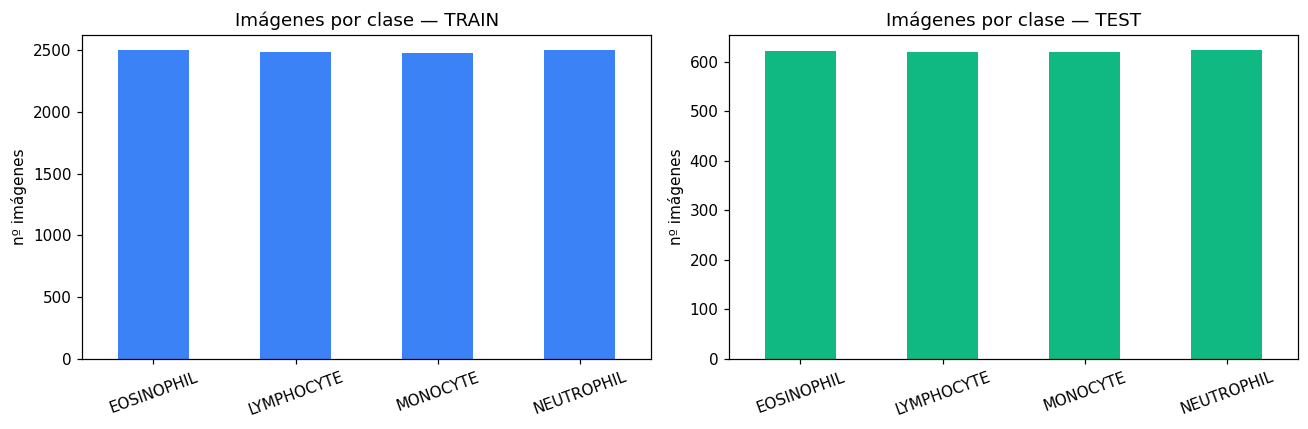

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_counts.drop("TOTAL").plot.bar(y="train", ax=axes[0], color="#3b82f6", legend=False)
axes[0].set_title("Imágenes por clase — TRAIN")
axes[0].set_ylabel("nº imágenes")
axes[0].tick_params(axis="x", rotation=20)

df_counts.drop("TOTAL").plot.bar(y="test", ax=axes[1], color="#10b981", legend=False)
axes[1].set_title("Imágenes por clase — TEST")
axes[1].set_ylabel("nº imágenes")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_balance.png", dpi=120, bbox_inches="tight")
plt.show()

**Observation.** The dataset is approximately balanced across the 4 classes
(~2,400–2,500 images per class in TRAIN and ~620 in TEST). Applying
*class weighting* or aggressive *oversampling* during modeling will not be necessary.

## 4. Visual Inspection of Samples

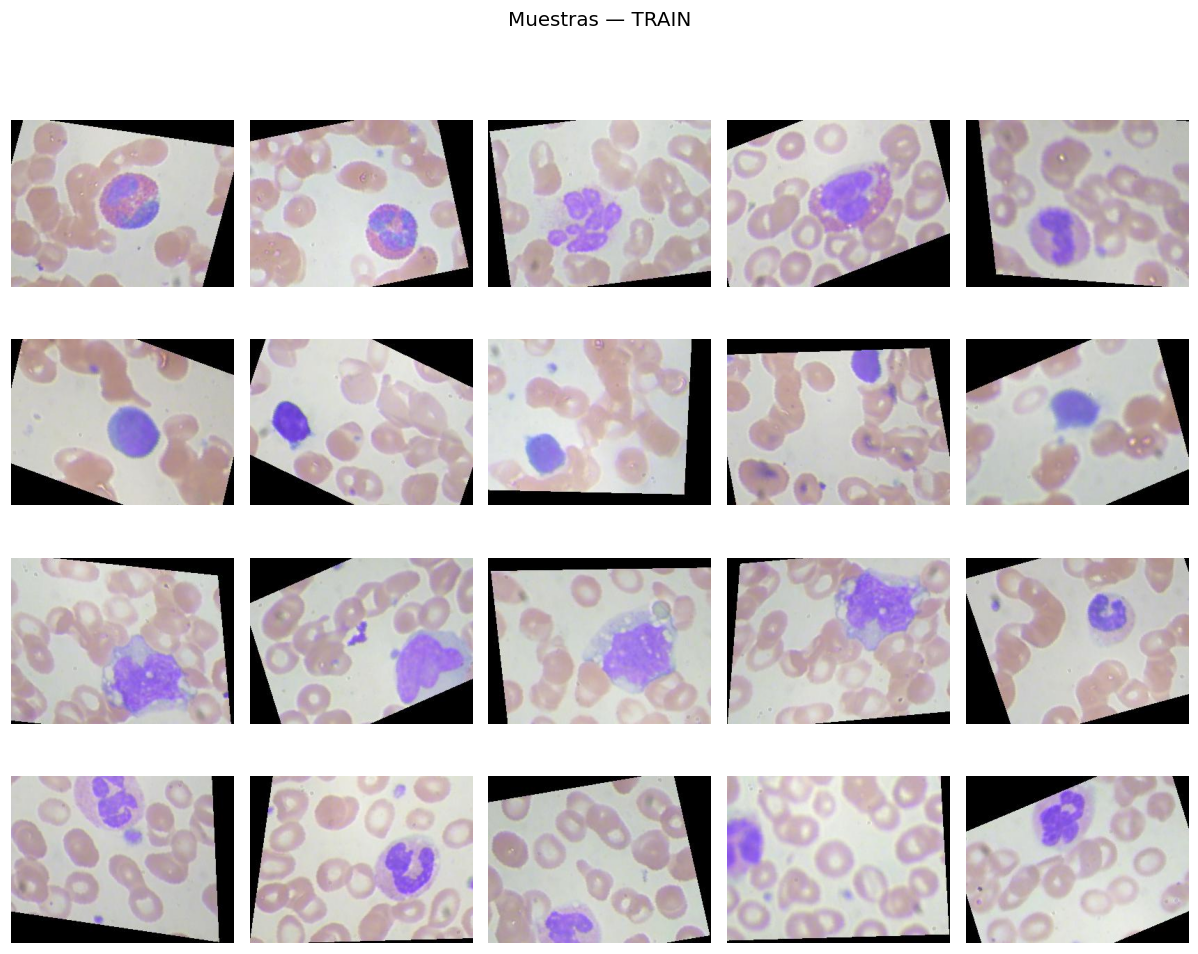

In [13]:
def show_grid(root, n_per_class=5):
    fig, axes = plt.subplots(len(CLASSES), n_per_class,
                             figsize=(2.2 * n_per_class, 2.2 * len(CLASSES)))
    for i, c in enumerate(CLASSES):
        files = sorted((root / c).glob("*"))[:n_per_class]
        for j, f in enumerate(files):
            img = Image.open(f).convert("RGB")
            ax = axes[i, j]
            ax.imshow(img)
            ax.axis("off")
            if j == 0:
                ax.set_ylabel(c, rotation=0, ha="right", va="center", fontsize=11)
    plt.suptitle(f"Muestras — {root.name}", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"samples_{root.name}.png", dpi=120, bbox_inches="tight")
    plt.show()

show_grid(TRAIN_DIR, n_per_class=5)

## 5. Image Properties

In [ ]:
# We sample 300 images to quickly estimate sizes and statistics
sample_paths = []
for c in CLASSES:
    files = list((TRAIN_DIR / c).glob("*.jpeg")) + list((TRAIN_DIR / c).glob("*.jpg"))
    sample_paths += files[:75]

shapes, means, stds = [], [], []
for p in sample_paths:
    img = np.asarray(Image.open(p).convert("RGB"), dtype=np.float32) / 255.0
    shapes.append(img.shape)
    means.append(img.mean(axis=(0, 1)))
    stds.append(img.std(axis=(0, 1)))

shapes_df = pd.DataFrame(shapes, columns=["H", "W", "C"])
print("Tamaño único en muestra:", shapes_df.drop_duplicates().to_dict("records"))
print()
print(f"Media RGB (sobre muestra): {np.mean(means, axis=0).round(4)}")
print(f"Desv. RGB (sobre muestra): {np.mean(stds,  axis=0).round(4)}")


Tamaño único en muestra: [{'H': 240, 'W': 320, 'C': 3}]

Media RGB (sobre muestra): [0.6802 0.6419 0.6606]
Desv. RGB (sobre muestra): [0.2599 0.2591 0.2564]


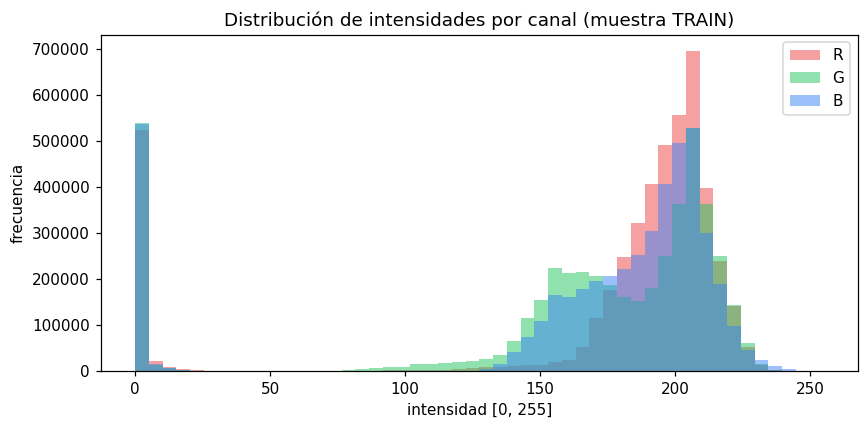

In [ ]:
# Intensity histogram per channel (over the sample)
all_pixels = []
for p in sample_paths[:60]:
    arr = np.asarray(Image.open(p).convert("RGB"), dtype=np.uint8)
    all_pixels.append(arr.reshape(-1, 3))
all_pixels = np.concatenate(all_pixels, axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#ef4444", "#22c55e", "#3b82f6"]
labels = ["R", "G", "B"]
for i in range(3):
    ax.hist(all_pixels[:, i], bins=50, alpha=0.5, color=colors[i], label=labels[i])
ax.set_title("Distribución de intensidades por canal (muestra TRAIN)")
ax.set_xlabel("intensidad [0, 255]")
ax.set_ylabel("frecuencia")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rgb_hist.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. EDA Conclusions

- **Size:** ~9,957 images in TRAIN and ~2,487 in TEST, balanced across the 4 classes
  (≈ 2,490 train / ≈ 620 test per class).
- **Original resolution:** 320×240 px RGB. For *from-scratch* models (LeNet and reduced
  VGG-11) we will resize to **64×64** to speed up training on CPU/Colab.
  For Transfer Learning with ResNet-18 / VGG-16 we will use **224×224** (standard
  ImageNet input size).
- **Color and morphology:** classes differ in shape, size, and staining patterns
  (HEMATOXYLIN-EOSIN). Color and texture are very strong discriminative signals —
  it is advisable to keep all 3 channels and apply per-channel normalization.
- **Balance:** *class weighting* is not required; standard `CrossEntropyLoss` can be used.
- **Reasonable augmentations:** horizontal/vertical flips, small rotations,
  brightness/contrast variations. Do *not* apply color inversions.